<a href="https://colab.research.google.com/github/kauazin05/CIAO_KKG_2026/blob/main/AULA_07/lab01_aula07_ciao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[LAB 01 - SUCESSO] Melhor Caminho: [0, 1, 3, 4, 2, 0] | Custo: 70


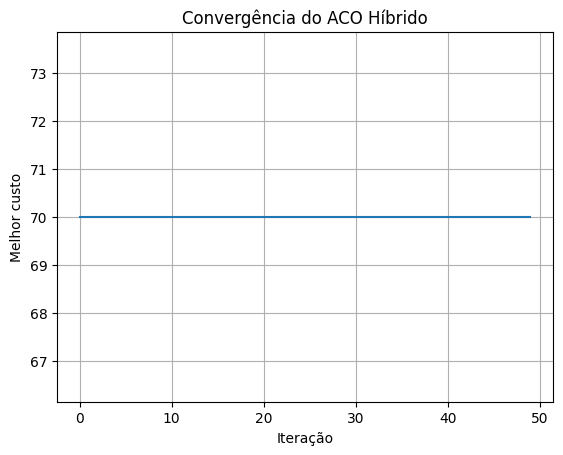

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42) #inicializa o gerador de números pseudoaleatórios do NumPy com valor específico de 42. Garante que a parte "aleatória" do algoritmo (escolha de nós pelas formigas) seja sempre a mesma a cada execução, facilitando a análise e a comparação de resultados.

# Matriz de Distâncias entre 5 Nós de Rede (Grafo)
dist_matrix = np.array([
    [0, 10, 15, 20, 25],
    [10, 0, 35, 25, 30],
    [15, 35, 0, 30, 5],
    [20, 25, 30, 0, 15],
    [25, 30, 5, 15, 0]
])

num_nodes = len(dist_matrix)

num_ants = 10
num_iterations = 50

alpha = 1.0   # Influência do Feromônio
beta = 2.0    # Influência da Visibilidade/Heurística
rho = 0.1     # Taxa de Evaporação

pheromone = np.ones((num_nodes, num_nodes))

best_cost = float('inf')
best_path = None

convergence = []


def local_search_2opt(path, matrix):
    """
    Busca Local 2-opt.
    Tenta melhorar a rota realizando inversões
    de trechos do caminho.
    """

    improved = True

    best_local_path = list(path)

    best_local_cost = sum(
        matrix[best_local_path[i], best_local_path[i + 1]]
        for i in range(len(best_local_path) - 1)
    )

    while improved:

        improved = False

        for i in range(1, len(best_local_path) - 2):

            for j in range(i + 1, len(best_local_path) - 1):

                new_path = (
                    best_local_path[:i]
                    + best_local_path[i:j + 1][::-1]
                    + best_local_path[j + 1:]
                )

                new_cost = sum(
                    matrix[new_path[k], new_path[k + 1]]
                    for k in range(len(new_path) - 1)
                )

                if new_cost < best_local_cost:

                    best_local_cost = new_cost
                    best_local_path = new_path
                    improved = True

    return best_local_path, best_local_cost

# ==========================================================
# ACO HÍBRIDO
# ==========================================================

for it in range(num_iterations):

    paths = []
    costs = []

    for ant in range(num_ants):

        path = [0]

        unvisited = list(range(1, num_nodes))

        while unvisited:

            curr = path[-1]

            probabilities = []

            for nxt in unvisited:

                tau = pheromone[curr][nxt] ** alpha

                eta = (1.0 / dist_matrix[curr][nxt]) ** beta

                probabilities.append(tau * eta)

            probabilities = np.array(probabilities)

            probabilities /= probabilities.sum()

            nxt_node = np.random.choice(
                unvisited,
                p=probabilities
            )

            path.append(nxt_node)

            unvisited.remove(nxt_node)

        # Retorna ao nó inicial
        path.append(0)

        # Busca Local 2-opt
        path, cost = local_search_2opt(
            path,
            dist_matrix
        )

        paths.append(path)
        costs.append(cost)

        # Atualiza melhor solução global
        if cost < best_cost:

            best_cost = cost
            best_path = path.copy()

    # Evaporação
    pheromone *= (1 - rho)

    # Depósito
    for path, cost in zip(paths, costs):

        for i in range(len(path) - 1):

            pheromone[path[i]][path[i + 1]] += 1.0 / cost

    convergence.append(best_cost)

print(
    f"[LAB 01 - SUCESSO] "
    f"Melhor Caminho: {[int(node) for node in best_path]} | "  # Convert to standard Python int
    f"Custo: {best_cost}"
)

# Gráfico de convergência
plt.plot(convergence)
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Convergência do ACO Híbrido")
plt.grid()
plt.show()
